In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mcap_ros2.decoder import DecoderFactory
from mcap.reader import make_reader


# file_name = '/mnt/c/bag/gtc_lapos1_2024-10-29_13-46_0.mcap'
# file_name = '/mnt/c/bag/gtc_kocka1_2024-10-29__13-41.mcap'
# file_name = '/mnt/c/bag/gtc_kocka1_filtered.mcap'
# file_name = '/mnt/c/bag/gtc_lapos1_filtered.mcap'
# file_name = '/mnt/c/bag/lexus-2023-07-18-campus.mcap'
file_name = '/mnt/c/bag/lokalizacio02_no_cam_lexus3_2026-03-06_09-37_0.mcap'
with open(file_name, "rb") as f:
    reader = make_reader(f, decoder_factories=[DecoderFactory()])
    #list all topics and types
    channels = reader.get_summary().channels.items()
    print("Available topics are the following:")
    for index, (channel_key, channel_value) in enumerate(channels):
        print("%2d. topic: %s" % (index+1, channel_value.topic))
    print("")

    # ndtp: /localization/pose_estimator/pose
    # nova: /lexus3/gps/nova/current_pose


    #iterate over all messages
    i = 0
    # pose nova type is geometry_msgs/msg/Pose
    pose_nova = []
    pose_ndtp = []

    for schema, channel, message, ros_msg in reader.iter_decoded_messages():
        if channel.topic == "/lexus3/gps/nova/current_pose":
            # print("%s -- %d || %s" % (channel.topic, message.log_time, ros_msg.pose.position.x))
            pose_nova.append(ros_msg)
        if channel.topic == "/localization/pose_estimator/pose":
            pose_ndtp.append(ros_msg)
        if (i % 1000 == 0): # at every 1000th message print a .
            print(".", end="")
        i += 1


/home/he1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Available topics are the following:
 1. topic: /lexus3/gps/nova/current_pose
 2. topic: /tf
 3. topic: /vehicle/status/velocity_status
 4. topic: /tf_static
 5. topic: /localization/pose_estimator/pose_with_covariance
 6. topic: /localization/pose_estimator/pose
 7. topic: /sensing/imu/data
 8. topic: /sensing/gps
 9. topic: /vehicle/status/steering_wheel_status

.............................................................................................................................................................................................................................................................

/tmp/ipykernel_10256/2075904147.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter([p.pose.position.x for p in pose_nova], [p.pose.position.y for p in pose_nova], label='nova', s=0.2, cmap=cm)
/tmp/ipykernel_10256/2075904147.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter([p.pose.position.x for p in pose_ndtp], [p.pose.position.y for p in pose_ndtp], label='ndtp', s=0.1, cmap=cm)


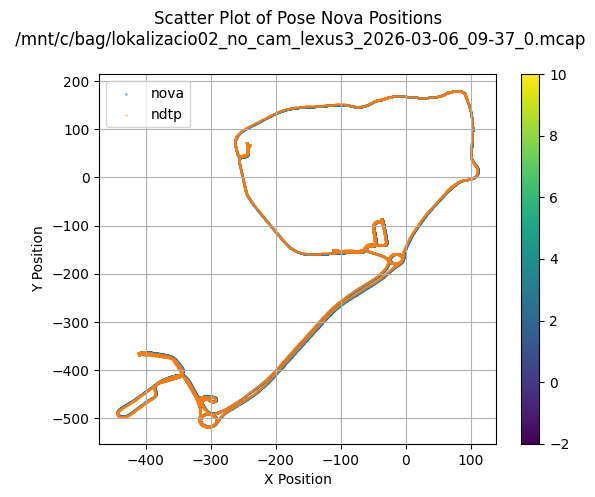

In [2]:


# Create a rainbow colormap with 12 bins
cm = plt.get_cmap('rainbow', 12).reversed()

# Plotting the positions
# Plotting the positions
plt.figure()
plt.scatter([p.pose.position.x for p in pose_nova], [p.pose.position.y for p in pose_nova], label='nova', s=0.2, cmap=cm)
plt.clim(-2, 10)  # Set color limits
plt.scatter([p.pose.position.x for p in pose_ndtp], [p.pose.position.y for p in pose_ndtp], label='ndtp', s=0.1, cmap=cm)
plt.clim(-2, 10)  # Set color limits


# Add labels and title
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Scatter Plot of Pose Nova Positions\n '+ file_name + '\n')
plt.colorbar()
plt.legend()
plt.grid(True)
plt.show()

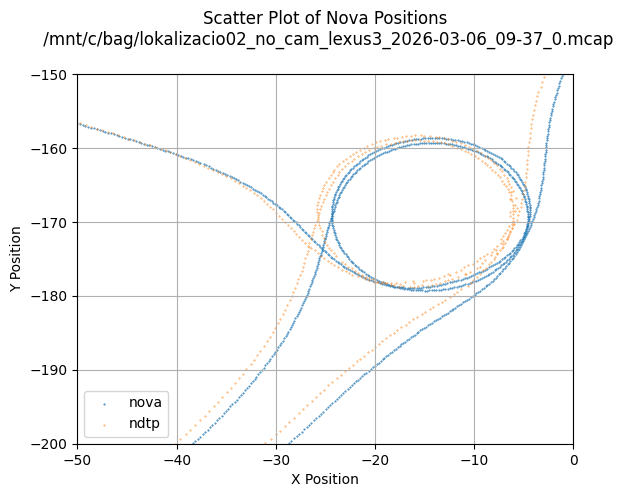

In [3]:
# zoomed in plot x: -50 to 0 and y: -200 to -150
plt.figure()
plt.scatter([p.pose.position.x for p in pose_nova], [p.pose.position.y for p in pose_nova], label='nova', s=0.2)
plt.clim(-2, 10)  # Set color limits
plt.scatter([p.pose.position.x for p in pose_ndtp], [p.pose.position.y for p in pose_ndtp], label='ndtp', s=0.1)
plt.clim(-2, 10)  # Set color limits

# Add labels and title
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Scatter Plot of Nova Positions\n '+ file_name + '\n')
# plt.colorbar()
# set_aspect equal

plt.legend()
plt.xlim(-50, 0)
plt.ylim(-200, -150)
plt.grid(True)
plt.show()

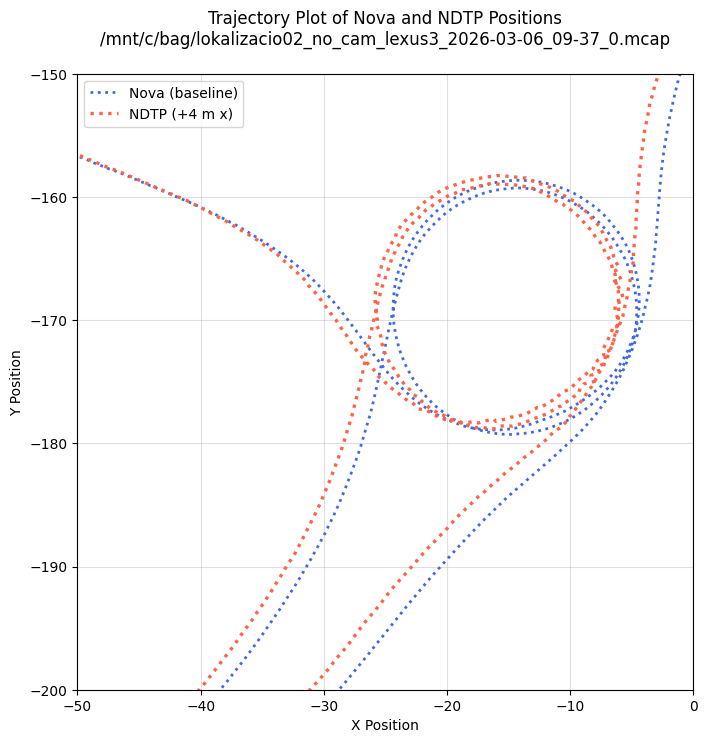

In [4]:
# plot again with a constant +0 m x offset on NDTP using line plots
fig, ax = plt.subplots(figsize=(10, 8))

x_nova = [p.pose.position.x for p in pose_nova]
y_nova = [p.pose.position.y for p in pose_nova]
x_ndtp_offset = [p.pose.position.x + 0 for p in pose_ndtp]
y_ndtp = [p.pose.position.y for p in pose_ndtp]

ax.plot(x_nova, y_nova, color='royalblue', linewidth=2.0, linestyle='dotted', label='Nova (baseline)')
ax.plot(x_ndtp_offset, y_ndtp, color='tomato', linewidth=2.4, linestyle='dotted', label='NDTP (+4 m x)')

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Trajectory Plot of Nova and NDTP Positions\n' + file_name + '\n')
ax.legend()
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-50, 0)
ax.set_ylim(-200, -150)
ax.grid(True, alpha=0.4)
plt.show()


Nova üzenetek: 15345, NDTP üzenetek: 7599


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



=== SVD rigid illesztés ===
  Rotáció  : +0.0274 fok
  Δx (t_x) : +0.772 m
  Δy (t_y) : +0.076 m

=== Maradék eltérés illesztés után ===
  Δx  átlag : +0.000 m   std: 1.188 m
  Δy  átlag : +0.000 m   std: 1.378 m
  2D  átlag : 1.705 m   std: 0.636 m
  2D  max   : 3.330 m


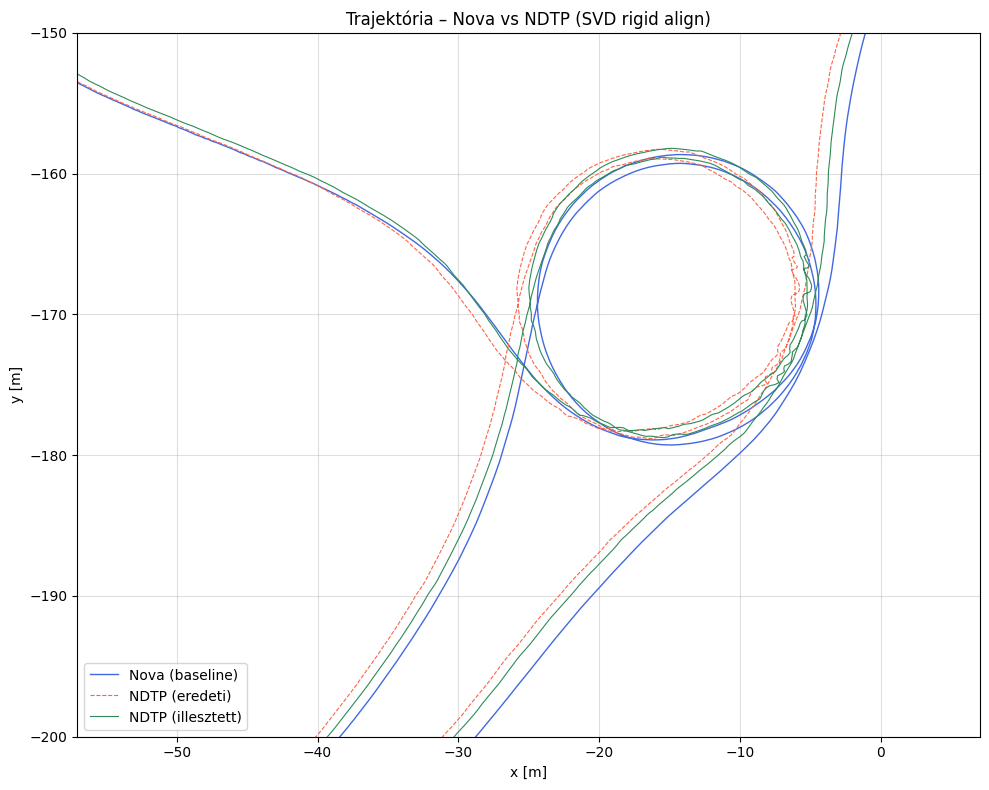

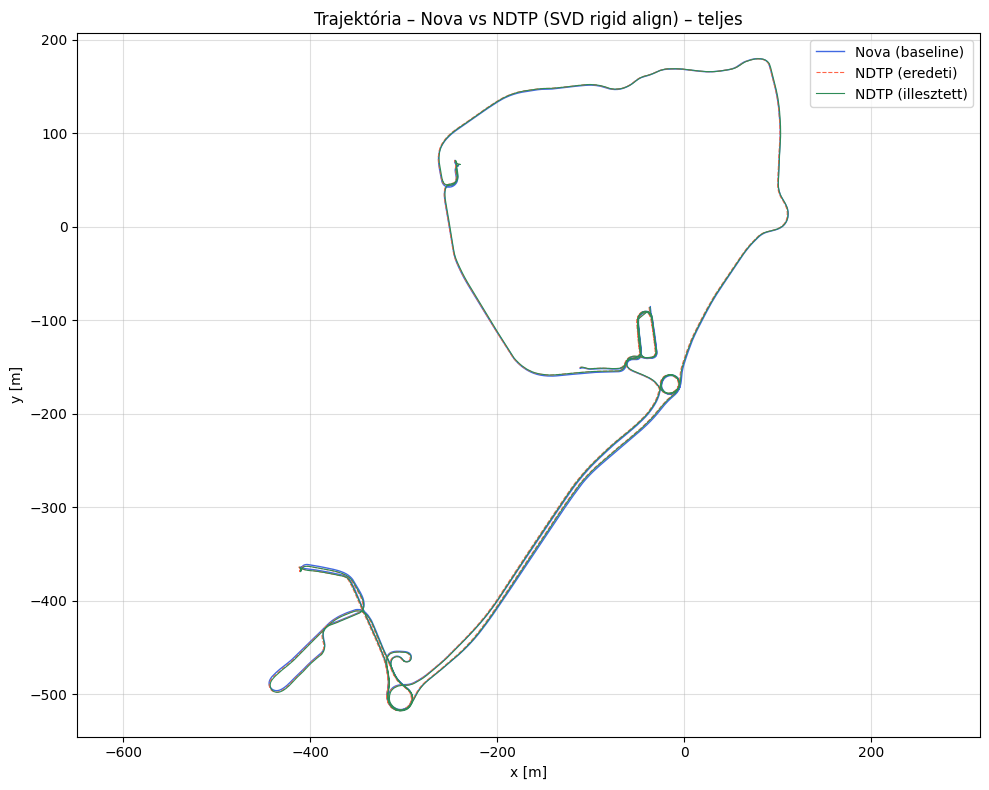

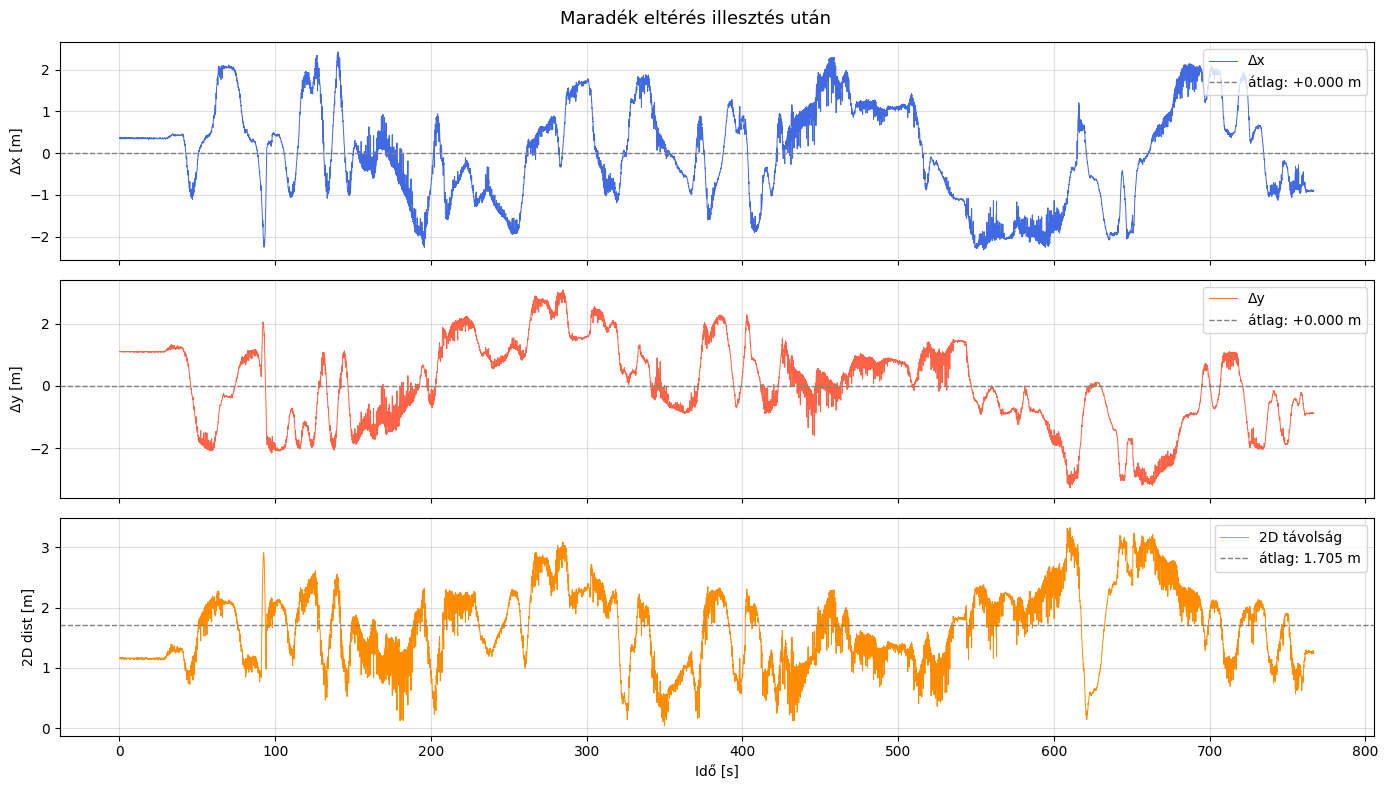

In [12]:
print(f"\nNova üzenetek: {len(pose_nova)}, NDTP üzenetek: {len(pose_ndtp)}")


# --- Segédfüggvények ---
def get_timestamps(poses):
    return np.array([
        p.header.stamp.sec + p.header.stamp.nanosec * 1e-9
        for p in poses
    ])

def get_xy(poses):
    xs = np.array([p.pose.position.x for p in poses])
    ys = np.array([p.pose.position.y for p in poses])
    return xs, ys


# --- Adatok kinyerése ---
t_nova = get_timestamps(pose_nova)
t_ndtp = get_timestamps(pose_ndtp)

x_nova, y_nova = get_xy(pose_nova)
x_ndtp, y_ndtp = get_xy(pose_ndtp)


# --- Interpoláció: NDTP -> Nova időtengelyére (átfedő tartomány) ---
t_start = max(t_nova[0], t_ndtp[0])
t_end   = min(t_nova[-1], t_ndtp[-1])

mask_nova = (t_nova >= t_start) & (t_nova <= t_end)
t_ref = t_nova[mask_nova]

x_nova_c = x_nova[mask_nova]
y_nova_c = y_nova[mask_nova]

x_ndtp_i = np.interp(t_ref, t_ndtp, x_ndtp)
y_ndtp_i = np.interp(t_ref, t_ndtp, y_ndtp)


# --- SVD-alapú globális 2D rigid illesztés ---
P = np.column_stack([x_ndtp_i, y_ndtp_i])   # forrás: NDTP
Q = np.column_stack([x_nova_c, y_nova_c])   # cél:    Nova (baseline)

p_mean = P.mean(axis=0)
q_mean = Q.mean(axis=0)

P_c = P - p_mean
Q_c = Q - q_mean

H = P_c.T @ Q_c
U, S, Vt = np.linalg.svd(H)

d = np.linalg.det(Vt.T @ U.T)
D = np.diag([1, d])
R = Vt.T @ D @ U.T

t_vec = q_mean - R @ p_mean

P_aligned = (R @ P.T).T + t_vec
x_ndtp_al = P_aligned[:, 0]
y_ndtp_al = P_aligned[:, 1]

angle_deg = np.degrees(np.arctan2(R[1, 0], R[0, 0]))


# --- Maradék eltérés illesztés után ---
dx_al   = x_nova_c - x_ndtp_al
dy_al   = y_nova_c - y_ndtp_al
dist_al = np.sqrt(dx_al**2 + dy_al**2)
t_plot  = t_ref - t_ref[0]


# --- Eredmények ---
print(f"\n=== SVD rigid illesztés ===")
print(f"  Rotáció  : {angle_deg:+.4f} fok")
print(f"  Δx (t_x) : {t_vec[0]:+.3f} m")
print(f"  Δy (t_y) : {t_vec[1]:+.3f} m")

print(f"\n=== Maradék eltérés illesztés után ===")
print(f"  Δx  átlag : {np.mean(dx_al):+.3f} m   std: {np.std(dx_al):.3f} m")
print(f"  Δy  átlag : {np.mean(dy_al):+.3f} m   std: {np.std(dy_al):.3f} m")
print(f"  2D  átlag : {np.mean(dist_al):.3f} m   std: {np.std(dist_al):.3f} m")
print(f"  2D  max   : {np.max(dist_al):.3f} m")


# --- Plot 1: trajektória ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(x_nova_c,  y_nova_c,  color='royalblue', linewidth=1.0, label='Nova (baseline)')
ax.plot(x_ndtp_i,  y_ndtp_i,  color='tomato',    linewidth=0.8, linestyle='--', label='NDTP (eredeti)')
ax.plot(x_ndtp_al, y_ndtp_al, color='seagreen',  linewidth=0.8, linestyle='-',  label='NDTP (illesztett)')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Trajektória – Nova vs NDTP (SVD rigid align)')
ax.legend()
# zoomed in plot x: -50 to 0 and y: -200 to -150 
ax.axis('equal')
ax.set_xlim(-50, 0)
ax.set_ylim(-200, -150)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- Plot 1b: trajektória – teljes kép (zoom nélkül) ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(x_nova_c,  y_nova_c,  color='royalblue', linewidth=1.0, label='Nova (baseline)')
ax.plot(x_ndtp_i,  y_ndtp_i,  color='tomato',    linewidth=0.8, linestyle='--', label='NDTP (eredeti)')
ax.plot(x_ndtp_al, y_ndtp_al, color='seagreen',  linewidth=0.8, linestyle='-',  label='NDTP (illesztett)')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Trajektória – Nova vs NDTP (SVD rigid align) – teljes')
ax.legend()
ax.axis('equal')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- Plot 2: maradék eltérés időben ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Maradék eltérés illesztés után", fontsize=13)

axes[0].plot(t_plot, dx_al, color='royalblue', linewidth=0.7, label='Δx')
axes[0].axhline(np.mean(dx_al), color='gray', linewidth=1, linestyle='--',
                label=f'átlag: {np.mean(dx_al):+.3f} m')
axes[0].set_ylabel('Δx [m]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_plot, dy_al, color='tomato', linewidth=0.7, label='Δy')
axes[1].axhline(np.mean(dy_al), color='gray', linewidth=1, linestyle='--',
                label=f'átlag: {np.mean(dy_al):+.3f} m')
axes[1].set_ylabel('Δy [m]')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.4)

axes[2].plot(t_plot, dist_al, color='darkorange', linewidth=0.7, label='2D távolság')
axes[2].axhline(np.mean(dist_al), color='gray', linewidth=1, linestyle='--',
                label=f'átlag: {np.mean(dist_al):.3f} m')
axes[2].set_ylabel('2D dist [m]')
axes[2].set_xlabel('Idő [s]')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
# plt.savefig("pose_diff_aligned.png", dpi=150)
plt.show()

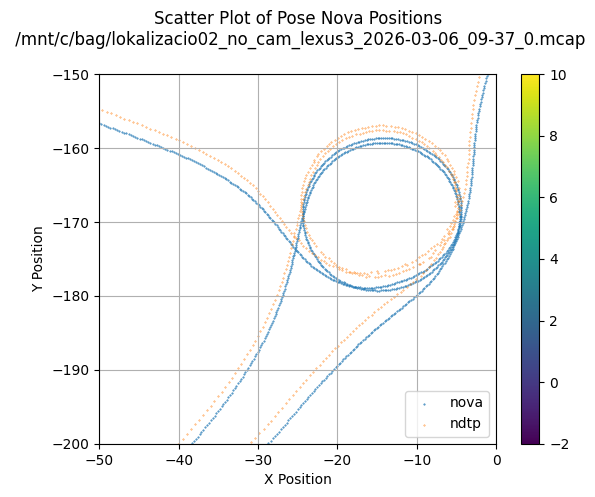

In [ ]:
# zoomed in plot x: -50 to 0 and y: -200 to -150  add constant x 1.211 m y +1.354 m to ndtp pose and plot again

plt.figure()
plt.scatter([p.pose.position.x for p in pose_nova], [p.pose.position.y for p in pose_nova], label='nova', s=0.2)
plt.clim(-2, 10)  # Set color limits
plt.scatter([p.pose.position.x + 1.211 for p in pose_ndtp], [p.pose.position.y + 1.354 for p in pose_ndtp], label='ndtp', s=0.1)
plt.clim(-2, 10)  # Set color limits
# Add labels and title
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Scatter Plot of Pose Nova Positions\n '+ file_name + '\n')
plt.colorbar()
plt.legend()
plt.xlim(-50, 0)
plt.ylim(-200, -150)
plt.grid(True)
plt.show()